In [2]:
from datasets import load_dataset

ds = load_dataset("phiyodr/InpaintCOCO")

/opt/anaconda3/envs/mllmaaj/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 1260/1260 [00:01<00:00, 1049.49 examples/s]


In [3]:
print(ds)

DatasetDict({
    test: Dataset({
        features: ['concept', 'coco_caption', 'coco_image', 'inpaint_caption', 'inpaint_image', 'mask', 'worker', 'coco_details', 'inpaint_details', 'mask_details'],
        num_rows: 1260
    })
})


In [4]:
sample = ds["test"][0]
print(sample.keys())


dict_keys(['concept', 'coco_caption', 'coco_image', 'inpaint_caption', 'inpaint_image', 'mask', 'worker', 'coco_details', 'inpaint_details', 'mask_details'])


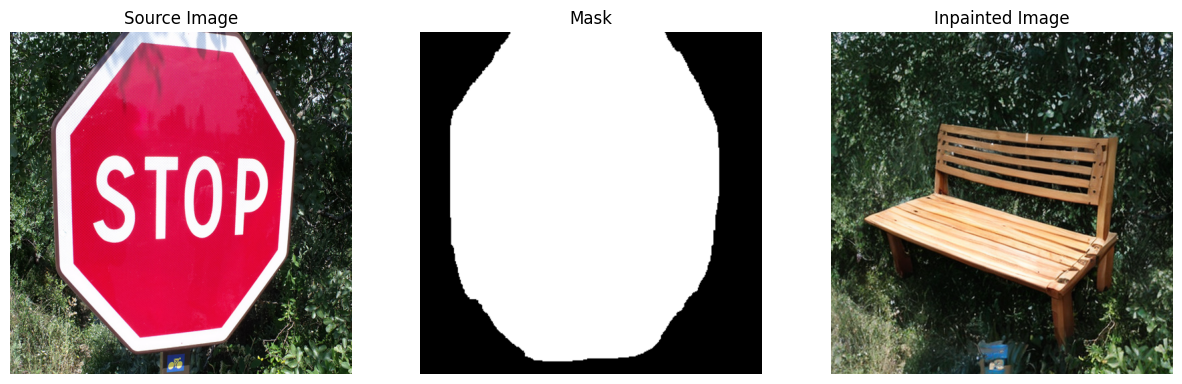

A wooden bench in the bushes.


In [7]:
import matplotlib.pyplot as plt

def show_sample(sample):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(sample["coco_image"])
    axes[0].set_title("Source Image")
    axes[0].axis("off")

    axes[1].imshow(sample["mask"])
    axes[1].set_title("Mask")
    axes[1].axis("off")

    axes[2].imshow(sample["inpaint_image"])
    axes[2].set_title("Inpainted Image")
    axes[2].axis("off")

    plt.show()

show_sample(ds["test"][0])
print(ds["test"][0]["inpaint_caption"])


In [8]:
print(sample["mask_details"])


{'height_factor': 25, 'prompt': 'stop sign', 'prompts_used': 1, 'width_factor': 25}


In [9]:
print(sample["inpaint_details"])


{'duration': 18, 'guidance_scale': 7.5, 'num_inference_steps': 100, 'prompt': 'wooden bench', 'prompts_used': 2, 'quality': 'very good'}


In [11]:
for i in range(3):
    s = ds["test"][i]
    print("=" * 40)
    print("Concept:", s["concept"])
    print("Mask prompt:", s["mask_details"]["prompt"])
    print("Inpaint prompt:", s["inpaint_details"]["prompt"])


Concept: object
Mask prompt: stop sign
Inpaint prompt: wooden bench
Concept: object
Mask prompt: pizza
Inpaint prompt: sandwich
Concept: object
Mask prompt: dog
Inpaint prompt: walking black cat


In [13]:
from collections import Counter

concepts = [s["concept"] for s in ds["test"]]
Counter(concepts)


Counter({'color': 465, 'object': 452, 'size': 343})

In [15]:
import numpy as np

def mask_ratio(mask):
    mask_np = np.array(mask.convert("L"))
    return (mask_np > 0).mean()

ratios = [mask_ratio(s["mask"]) for s in ds["test"]]

print("Min:", min(ratios))
print("Max:", max(ratios))
print("Mean:", sum(ratios)/len(ratios))


Min: 0.00698089599609375
Max: 1.0
Mean: 0.29456737457759796


In [17]:
lengths = [len(s["inpaint_details"]["prompt"].split()) for s in ds["test"]]
print(min(lengths), max(lengths))


1 17


In [ ]:
import os
from datasets import load_dataset

dataset = load_dataset("phiyodr/inpaintCOCO")
out_root = "/raid/data/inpaintCOCO_export"

os.makedirs(out_root, exist_ok=True)

for i, s in enumerate(dataset["test"]):
    sample_dir = os.path.join(out_root, f"{i:04d}")
    os.makedirs(sample_dir, exist_ok=True)

    s["coco_image"].save(os.path.join(sample_dir, "source.png"))
    s["mask"].save(os.path.join(sample_dir, "mask.png"))
    s["inpaint_image"].save(os.path.join(sample_dir, "target.png"))

    with open(os.path.join(sample_dir, "prompt.txt"), "w") as f:
        f.write(s["inpaint_details"]["prompt"])
